In [2]:
from google.colab import files
uploaded = files.upload()

Saving New_AS_001.wav to New_AS_001.wav


In [3]:
file_path = "/content/New_AS_001.wav"


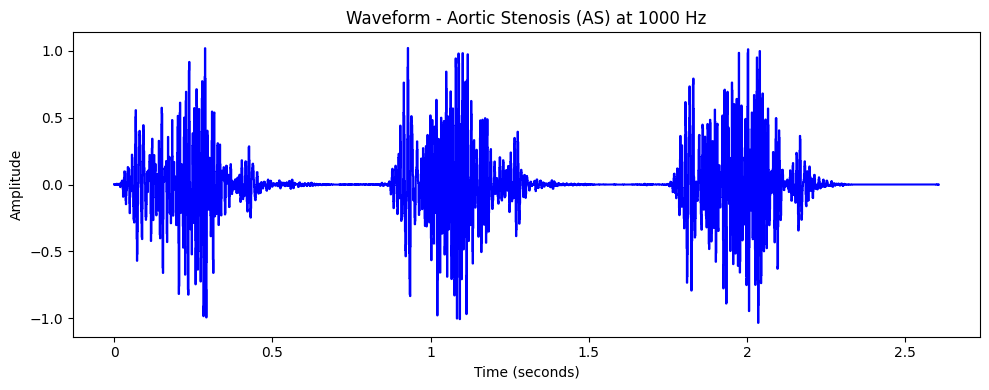

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


target_sr = 1000
y, sr = librosa.load(file_path, sr=target_sr)


n_fft = 256
hop_length = 64
D = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))

DB = librosa.amplitude_to_db(D, ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr, color='blue')

plt.title("Waveform - Aortic Stenosis (AS) at 1000 Hz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

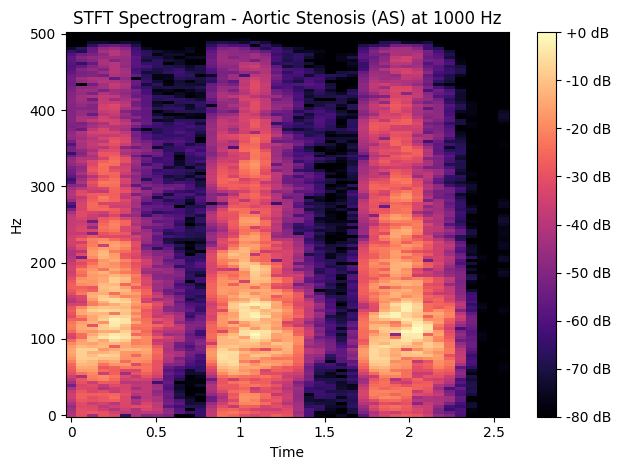

In [5]:
librosa.display.specshow(DB, sr=sr, hop_length=hop_length,
                         x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("STFT Spectrogram - Aortic Stenosis (AS) at 1000 Hz")
plt.tight_layout()
plt.show()

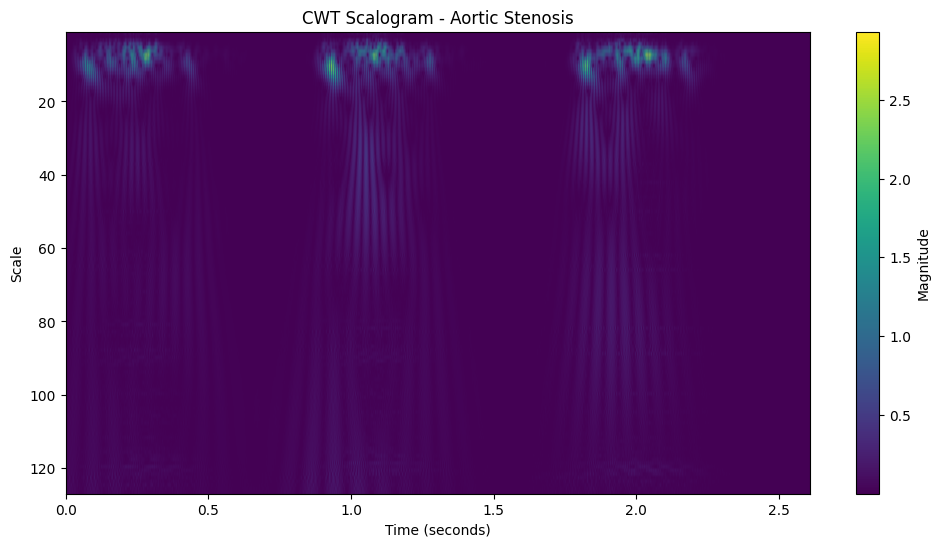

In [6]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pywt

file_path = "/content/New_AS_001.wav"
target_sr = 1000


y, sr = librosa.load(file_path, sr=target_sr)


scales = np.arange(1, 128)  # scale range
coefficients, frequencies = pywt.cwt(y, scales, 'morl', sampling_period=1/sr)

plt.figure(figsize=(12, 6))
plt.imshow(np.abs(coefficients), extent=[0, len(y)/sr, scales[-1], scales[0]],
           cmap='viridis', aspect='auto')
plt.title("CWT Scalogram - Aortic Stenosis")
plt.ylabel("Scale")
plt.xlabel("Time (seconds)")
plt.colorbar(label="Magnitude")
plt.show()


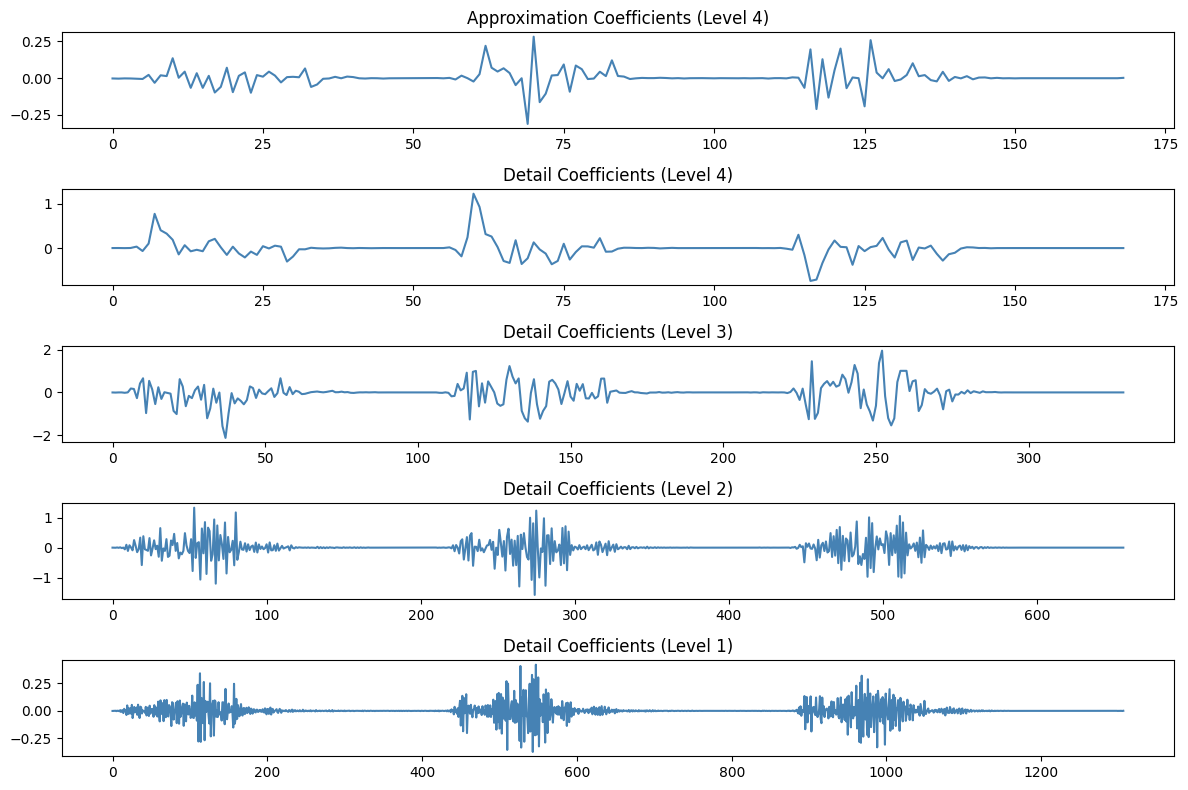

In [7]:
import pywt


wavelet = 'db4'
max_level = 4

coeffs = pywt.wavedec(y, wavelet, level=max_level)


plt.figure(figsize=(12, 8))
for i, coef in enumerate(coeffs):
    plt.subplot(len(coeffs), 1, i+1)
    plt.plot(coef, color='steelblue')
    if i == 0:
        plt.title(f"Approximation Coefficients (Level {max_level})")
    else:
        plt.title(f"Detail Coefficients (Level {max_level - i + 1})")
plt.tight_layout()
plt.show()
